In [ ]:
!nvidia-smi

Tue Apr 14 09:08:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install transformers datasets evaluate scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 34.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
!pip install -q transformers datasets gradio

In [ ]:
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from datasets import Dataset, DatasetDict

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DebertaTokenizer,
    DebertaForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving AIGTxt.xlsx - Form 2 final.csv to AIGTxt.xlsx - Form 2 final.csv


In [ ]:
df = pd.read_csv("AIGTxt.xlsx - Form 2 final.csv")
df

,text,generated
0,Photo-realistic image rendering using standard...,1.0
1,The Large Hadron Collider is exploring physics...,1.0
2,With the rapid development of mobile Internet ...,1.0
3,Most contour tracking methods can be grouped i...,1.0
4,Year 2010 is regarded as the breakthrough year...,1.0
...,...,...
7210,Urban areas are increasingly experiencing infr...,0.0
7211,While it is widely acknowledged that addressin...,0.0
7212,Educational practitioners and academics have i...,0.0
7213,"Within this space, established by the non-gove...",0.0


In [ ]:
# Step 1: Remove rows with missing values
df = df.dropna(subset=["text", "generated"])

# Step 2: Convert label to integer
df["generated"] = df["generated"].astype(int)

# Step 3: Rename column to 'label' (Trainer requires this)
df = df.rename(columns={"generated": "labels"})

# Step 4: Reset index
df = df.reset_index(drop=True)

/tmp/ipykernel_6530/4102432776.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["generated"] = df["generated"].astype(int)


In [ ]:
df

,text,labels
0,Photo-realistic image rendering using standard...,1
1,The Large Hadron Collider is exploring physics...,1
2,With the rapid development of mobile Internet ...,1
3,Most contour tracking methods can be grouped i...,1
4,Year 2010 is regarded as the breakthrough year...,1
...,...,...
7209,Urban areas are increasingly experiencing infr...,0
7210,While it is widely acknowledged that addressin...,0
7211,Educational practitioners and academics have i...,0
7212,"Within this space, established by the non-gove...",0


In [ ]:
print(df.dtypes)

text      object
labels     int64
dtype: object


In [ ]:
df = df[["text", "labels"]].copy()

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special chars
    text = text.strip()
    return text

df["text"] = df["text"].apply(clean_text)

In [ ]:
df["text"] = df["text"].str.replace("\n", " ", regex=False)
df["text"] = df["text"].str.replace("\t", " ", regex=False)

In [ ]:
dataset = Dataset.from_pandas(df)

print(dataset[0])


{'text': 'photorealistic image rendering using standard graphics  techniques is involved since geometry materials and light  transport must be simulated explicitly although existing  graphics algorithms excel at the task building and editing virtual environments is expensive and timeconsuming  that is because we have to model every aspect of the world  explicitly if we were able to render photorealistic images  using a model learned from data we could turn the process  of graphics rendering into a model learning and inference  problem then we could simplify the process of creating  new virtual worlds by training models on new datasets we  could even make it easier to customize environments by allowing users to simply specify the overall semantic structure rather than modeling geometry materials or lighting', 'labels': 1}


In [ ]:
dataset = dataset.train_test_split(test_size=0.2)

# train_dataset = dataset["train"]
# eval_dataset = dataset["test"]

In [ ]:

models = {
    "BERT": "answerdotai/ModernBERT-base",
    "RoBERTa": "roberta-base",
    "DeBERTa": "microsoft/deberta-base",
    "DistilBERT": "distilbert-base-uncased",
    "ELECTRA": "google/electra-base-discriminator"
}

In [ ]:
# model_name = "answerdotai/ModernBERT-base"
# tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# train_dataset = train_dataset.map(tokenize_function, batched=True)
# eval_dataset = eval_dataset.map(tokenize_function, batched=True)

In [ ]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)

#     return {
#         "accuracy": accuracy_score(labels, predictions),
#         "precision": precision_score(labels, predictions),
#         "recall": recall_score(labels, predictions),
#         "f1": f1_score(labels, predictions)
#     }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
results = {}

all_confusion_matrices = {}
all_roc = {}
trained_models = {}
trained_tokenizers = {}
error_tables = {}

for model_name, model_path in models.items():

    print(f"\nTraining {model_name}...\n")

    tokenizer = AutoTokenizer.from_pretrained(model_path)

    tokenized_dataset = dataset.map(tokenize_function, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        # logging_dir=f"./logs_{model_name}",
        load_best_model_at_end=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["test"],
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()

    trained_models[model_name] = model
    trained_tokenizers[model_name] = tokenizer

    predictions = trainer.predict(tokenized_dataset["test"])

    preds = np.argmax(predictions.predictions, axis=1)
    probs = predictions.predictions[:,1]
    labels = predictions.label_ids

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    results[model_name] = [acc, prec, rec, f1]

    cm = confusion_matrix(labels, preds)
    all_confusion_matrices[model_name] = cm

    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    all_roc[model_name] = (fpr, tpr, roc_auc)

    print(classification_report(labels, preds))


Training BERT...



Map:   0%|          | 0/5771 [00:00<?, ? examples/s]

Map:   0%|          | 0/1443 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.351080,0.201899,0.943867,0.961373,0.925620,0.943158
2,0.178577,0.321547,0.934858,0.971642,0.896694,0.932665


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       717
           1       0.96      0.92      0.94       726

    accuracy                           0.94      1443
   macro avg       0.94      0.94      0.94      1443
weighted avg       0.94      0.94      0.94      1443



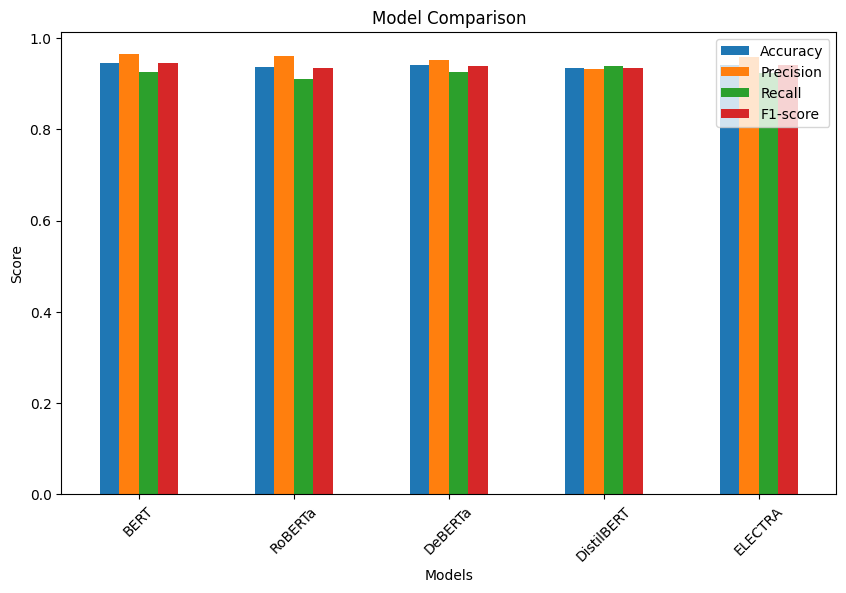

In [ ]:

#Performance Comparison Bar Graph
results_df = pd.DataFrame(results).T
results_df.columns = ["Accuracy", "Precision", "Recall", "F1-score"]

results_df.plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.legend()
plt.show()

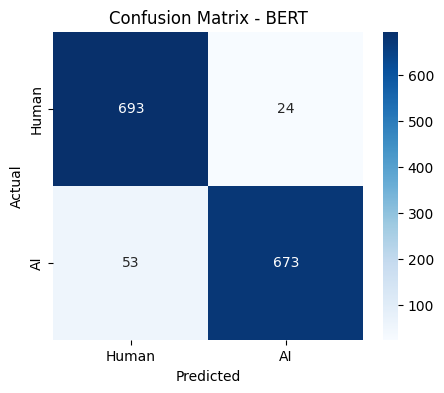

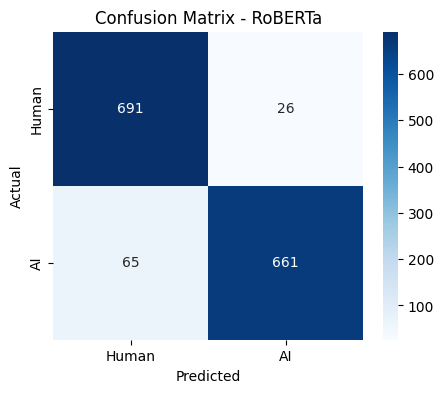

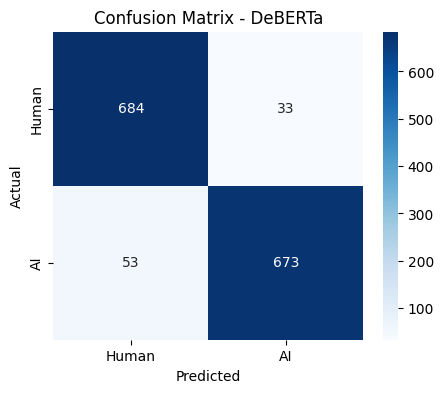

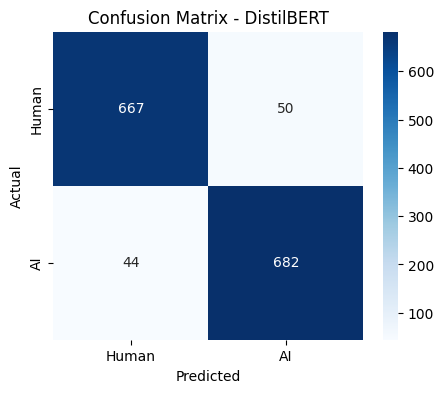

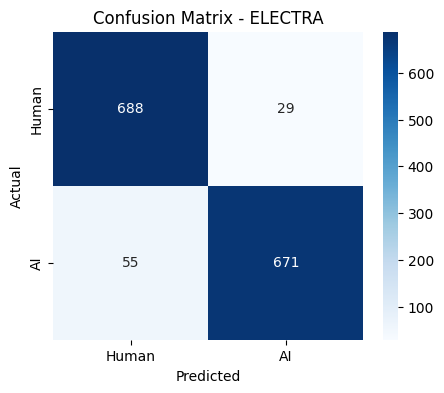

In [ ]:
#Confusion Matrix
for model_name, cm in all_confusion_matrices.items():

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Human", "AI"],
        yticklabels=["Human", "AI"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

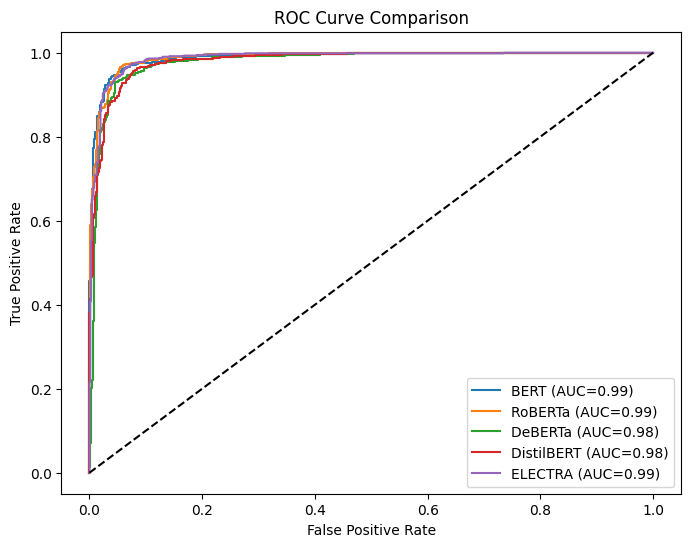

In [ ]:
#ROC Curve Comparison
plt.figure(figsize=(8,6))

for model_name, (fpr, tpr, roc_auc) in all_roc.items():

    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [ ]:
print(results_df)

            Accuracy  Precision    Recall  F1-score
BERT        0.946639   0.965567  0.926997  0.945889
RoBERTa     0.936937   0.962154  0.910468  0.935598
DeBERTa     0.940402   0.953258  0.926997  0.939944
DistilBERT  0.934858   0.931694  0.939394  0.935528
ELECTRA     0.941788   0.958571  0.924242  0.941094


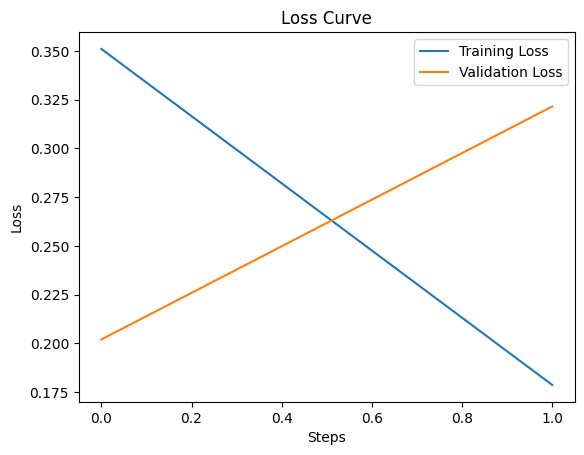

In [ ]:
#Training and Validation Loss Curve
log_history = trainer.state.log_history

train_loss = []
eval_loss = []

for log in log_history:

    if "loss" in log:
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# def test_models(input_text):

#     results = []

#     for model_name in trained_models:

#         model = trained_models[model_name].to(device)
#         tokenizer = trained_tokenizers[model_name]

#         inputs = tokenizer(
#             input_text,
#             return_tensors="pt",
#             truncation=True,
#             padding=True,
#             max_length=256
#         )

#         # Move inputs to same device
#         inputs = {k: v.to(device) for k, v in inputs.items()}

#         with torch.no_grad():
#             outputs = model(**inputs)

#         probs = F.softmax(outputs.logits, dim=1)

#         human_prob = probs[0][0].item()
#         ai_prob = probs[0][1].item()

#         prediction = "Human Written" if human_prob > ai_prob else "AI Generated"

#         results.append({
#             "Model": model_name,
#             "Prediction": prediction,
#             "Human Probability": human_prob,
#             "AI Probability": ai_prob
#         })

#     return pd.DataFrame(results)

In [ ]:
# import torch
# import torch.nn.functional as F
# import pandas as pd

# def test_models(input_text):

#     results = []

#     for model_name in trained_models:

#         model = trained_models[model_name]
#         tokenizer = trained_tokenizers[model_name]

#         inputs = tokenizer(
#             input_text,
#             return_tensors="pt",
#             truncation=True,
#             padding=True,
#             max_length=256
#         )

#         with torch.no_grad():
#             outputs = model(**inputs)

#         probs = F.softmax(outputs.logits, dim=1)

#         human_prob = probs[0][0].item()
#         ai_prob = probs[0][1].item()

#         prediction = "Human" if human_prob > ai_prob else "AI Generated"

#         results.append({
#             "Model": model_name,
#             "Prediction": prediction,
#             "Human Probability": human_prob,
#             "AI Probability": ai_prob
#         })

#     results_df = pd.DataFrame(results)

#     return results_df

In [ ]:
def test_models(input_text):

    results = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for model_name in trained_models:

        model = trained_models[model_name].to(device)
        tokenizer = trained_tokenizers[model_name]

        inputs = tokenizer(
            input_text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        )

        # move inputs to same device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)

        human_prob = probs[0][0].item()
        ai_prob = probs[0][1].item()

        prediction = "Human Written" if human_prob > ai_prob else "AI Generated"

        results.append({
            "Model": model_name,
            "Prediction": prediction,
            "Human Probability": human_prob,
            "AI Probability": ai_prob
        })

    return pd.DataFrame(results)

In [ ]:
input_text = "Cognitive neuroscience has made significant strides, in part due to advancements in neuroimaging techniques, such as Positron Emission Tomography (PET) and functional Magnetic Resonance Imaging (fMRI). One of its primary goals is to comprehend the functioning of the human brain. The dialogue between cognitive neuroscience and psychoanalysis is not a recent development, but in recent times, it has intensified in exploring the intricate relationship between mind and brain, a connection envisioned by Freud over a century ago and emphasized by Nobel Prize winner Kandel (1999), who posited that psychoanalysis still presents the most coherent and intellectually satisfying perspective on the mind, which can aid neurobiologists in planning their research. As of now, neuroscience does not offer a unified, universally accepted, and comprehensive theory of brain-mind function. Nonetheless, it remains an invaluable tool for investigating mind-brain structures and functions in both their physiological and pathological manifestations. While psychoanalysis flourished over a century ago, the initial fruitful dialogue it had with neuroscience has not yet culminated in a complete understanding of the biological underpinnings for all psychoanalytic theoretical frameworks. It is not necessarily the shared objective of psychoanalysts or neuroscientists to achieve this complete integration in their daily work. Although neuroscience and psychoanalysis share a common scientific focus on an in-depth analysis of the mind-brain system's functioning, they employ different investigative tools, methods, and terminologies, necessitating a clear separation and distinction between the two fields, while maintaining an ongoing and fruitful dialogue."

test_models(input_text)

,Model,Prediction,Human Probability,AI Probability
0,BERT,Human Written,0.999966,0.000034
1,RoBERTa,Human Written,0.997536,0.002464
2,DeBERTa,Human Written,0.921417,0.078583
3,DistilBERT,Human Written,0.968892,0.031108
4,ELECTRA,Human Written,0.990879,0.009121


In [ ]:
input_text = "Yesterday I went to the local market with my friend. We bought some vegetables and fruits. The weather was pleasant and the streets were full of people enjoying the evening."

test_models(input_text)

,Model,Prediction,Human Probability,AI Probability
0,BERT,AI Generated,0.018339,0.981661
1,RoBERTa,AI Generated,0.018090,0.981910
2,DeBERTa,AI Generated,0.021816,0.978184
3,DistilBERT,AI Generated,0.015628,0.984372
4,ELECTRA,AI Generated,0.021040,0.978960


In [ ]:
input_text = "Bali is a Hindu country. Bali is famous for its traditional dances. The dances are inspired by the Hindi faith. Most dances depict the story of good and evil. Watching the dances is a thrilling experience. Some of the notable attractions in Lombok include the magnificent Mount Rinjani, which is an active volcano. It is the second highest volcano in Indonesia. Art is the passion of the people in Bali. Batik paintings and statues are the most popular souvenirs. One will spot artists carving and painting on the streets, especially in Ubud. It is easy to see the charm in each island as a beautiful tourist destination. Majestic views, beautiful culture, white sandy beaches, and blue waters are magnets that attract visitors to the islands every year. Snorkeling and diving in the nearby Gili Islands are magnificent. Fish, starfish, turtles, and a coral reef are abundant in the waters. Bali and Lombok are part of the Indonesian Islands. Bali has some magnificent temples. The most important one is the Mother Temple, Besakih. The people in Lombok are mostly Muslims, with a small percentage of Hindus."
test_models(input_text)

,Model,Prediction,Human Probability,AI Probability
0,BERT,AI Generated,0.017570,0.982430
1,RoBERTa,AI Generated,0.016839,0.983161
2,DeBERTa,AI Generated,0.012020,0.987980
3,DistilBERT,AI Generated,0.012839,0.987161
4,ELECTRA,AI Generated,0.018916,0.981085


In [ ]:
input_text = "It has been observed that a few students are not attending BCT sessions. All such students are hereby instructed to attend the training session from tomorrow without fail. Otherwise, their guardians will be informed as well. Absentee students may face issues during the upcoming placement drive."
test_models(input_text)

,Model,Prediction,Human Probability,AI Probability
0,BERT,AI Generated,0.236219,0.763780
1,RoBERTa,AI Generated,0.088072,0.911928
2,DeBERTa,AI Generated,0.017214,0.982786
3,DistilBERT,AI Generated,0.022502,0.977498
4,ELECTRA,AI Generated,0.103438,0.896562


In [ ]:
# # Load model
# model = AutoModelForSequenceClassification.from_pretrained(
#     model_name,
#     num_labels=2
# )

# # Training arguments

# training_args = TrainingArguments(
#     output_dir="./results",
#     eval_strategy="epoch",
#     learning_rate=2e-5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=3,
#     weight_decay=0.01
# )

# # Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=eval_dataset,
#     processing_class=tokenizer,
#     compute_metrics=compute_metrics
# )

# trainer.train()

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.356062,0.192277,0.936937,0.909910,0.971154,0.939535
2,0.191489,0.318767,0.936244,0.962209,0.909341,0.935028


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.356062,0.192277,0.936937,0.909910,0.971154,0.939535
2,0.191489,0.318767,0.936244,0.962209,0.909341,0.935028
3,0.030002,0.313687,0.947332,0.944142,0.951923,0.948016


TrainOutput(global_step=2166, training_loss=0.16550030503576812, metrics={'train_runtime': 751.0028, 'train_samples_per_second': 23.053, 'train_steps_per_second': 2.884, 'total_flos': 1474885147018752.0, 'train_loss': 0.16550030503576812, 'epoch': 3.0})

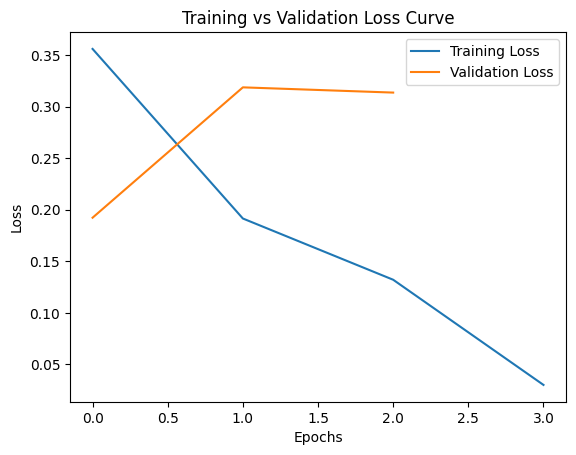

In [ ]:
# #Training & Validation Loss Curve
# # Extract loss from trainer
# train_loss = []
# eval_loss = []
# epochs = []

# for log in trainer.state.log_history:
#     if 'loss' in log and 'epoch' in log:
#         train_loss.append(log['loss'])
#         epochs.append(log['epoch'])
#     if 'eval_loss' in log:
#         eval_loss.append(log['eval_loss'])

# # Plot
# plt.figure()
# plt.plot(train_loss, label="Training Loss")
# plt.plot(eval_loss, label="Validation Loss")
# plt.xlabel("Epochs")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss Curve")
# plt.legend()
# plt.show()

In [ ]:


    # ==============================
    # ✅ ERROR ANALYSIS TABLE
    # ==============================
model_name = "microsoft/deberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

    #
# Get test texts (change "text" if needed)
test_texts = dataset["test"]["text"]

# Create DataFrame
df_errors = pd.DataFrame({
  "Text": test_texts,
  "Actual Label": labels,
  "Predicted Label": preds,
  "Probability_AI": probs
    })

# Convert labels (optional but recommended)
df_errors["Actual Label"] = df_errors["Actual Label"].map({0: "Human", 1: "AI"})
df_errors["Predicted Label"] = df_errors["Predicted Label"].map({0: "Human", 1: "AI"})

# Error column
df_errors["Error"] = (df_errors["Actual Label"] != df_errors["Predicted Label"]).astype(int)

# Store table
error_tables[model_name] = df_errors

# Misclassified samples
misclassified_df = df_errors[df_errors["Error"] == 1]

print(f"\n🔴 Misclassified samples for {model_name}:\n")
print(misclassified_df.head(10))

# Save files
df_errors.to_csv(f"{model_name}_full_results.csv", index=False)
misclassified_df.to_csv(f"{model_name}_errors.csv", index=False)


# =====================================
# ✅ DISPLAY TABLES FOR ALL MODELS
# =====================================
print("\n\n===== SAMPLE OUTPUT TABLES =====\n")

for model_name, df in error_tables.items():
      print(f"\n===== {model_name} =====\n")
      print(df.head(10))


# =====================================
# ✅ SUMMARY TABLE
# =====================================
summary = []

for model_name, df in error_tables.items():
      total = len(df)
      errors = df["Error"].sum()
      accuracy = (total - errors) / total

      summary.append({
        "Model": model_name,
        "Total Samples": total,
        "Errors": errors,
        "Accuracy": accuracy
    })

summary_df = pd.DataFrame(summary)

print("\n\n===== FINAL SUMMARY =====\n")
print(summary_df)


🔴 Misclassified samples for microsoft/deberta-base:

                                                  Text Actual Label  \
26   the solar dynamo generates magnetic flux withi...        Human   
33   fundamental progress in understanding the prop...           AI   
60   currently ai as a discipline and associated st...           AI   
62   genetic correlation is a component of shared h...           AI   
68   the field of bioinformatics has been enabled b...           AI   
73   nutrient enrichment referred to as eutrophicat...           AI   
94   genetics studies suggest that typical typea ar...           AI   
100  since the establishment of the arxiv repositor...           AI   
101  in social sciences panel studies have become i...           AI   
110  the importance of gene regulation cannot be ov...           AI   

    Predicted Label  Probability_AI  Error  
26               AI        0.113980      1  
33            Human       -1.293622      1  
60            Human       -2.

OSError: Cannot save file into a non-existent directory: 'microsoft'

In [ ]:
import pandas as pd

# Get original test texts
test_texts = dataset["test"]["text"]   # change "text" if your column name is different

# Create DataFrame
df_errors = pd.DataFrame({
    "Text": test_texts,
    "Actual Label": labels,
    "Predicted Label": preds,
    "Probability_AI": probs
})

# Add error column (1 = wrong, 0 = correct)
df_errors["Error"] = df_errors["Actual Label"] != df_errors["Predicted Label"]

# Optional: convert True/False → 1/0
df_errors["Error"] = df_errors["Error"].astype(int)

# Store full table
error_tables[model_name] = df_errors

In [ ]:
misclassified_df = df_errors[df_errors["Error"] == 1]

print(f"\nMisclassified samples for {model_name}:")
print(misclassified_df.head(10))


Misclassified samples for ELECTRA:
                                                  Text  Actual Label  \
26   the solar dynamo generates magnetic flux withi...             0   
33   fundamental progress in understanding the prop...             1   
60   currently ai as a discipline and associated st...             1   
62   genetic correlation is a component of shared h...             1   
68   the field of bioinformatics has been enabled b...             1   
73   nutrient enrichment referred to as eutrophicat...             1   
94   genetics studies suggest that typical typea ar...             1   
100  since the establishment of the arxiv repositor...             1   
101  in social sciences panel studies have become i...             1   
110  the importance of gene regulation cannot be ov...             1   

     Predicted Label  Probability_AI  Error  
26                 1        0.113980      1  
33                 0       -1.293622      1  
60                 0       -2.026

In [ ]:
df_errors.to_csv(f"{model_name}_full_results.csv", index=False)
misclassified_df.to_csv(f"{model_name}_errors.csv", index=False)

In [ ]:
for model_name, df in error_tables.items():
    print(f"\n===== {model_name} Results =====\n")
    print(df.head(10))


===== ELECTRA Results =====

                                                Text  Actual Label  \
0  in contemporary schubert calculus there is con...             0   
1  to cope with daily and seasonal environmental ...             0   
2  odds ratio or and risk ratio relative risk rr ...             1   
3  lowrank matrix recovery has emerged as a power...             0   
4  most people wear helmets during cycling drivin...             1   
5  augmented feedback serves as a valuable tool i...             0   
6  currently there exist over  languages spoken w...             0   
7  since the initial discovery of an extrasolar p...             0   
8  the need for change and reform becomes evident...             0   
9  the magnetosphereionosphere system encompasses...             0   

   Predicted Label  Probability_AI  Error  
0                0       -2.492258      0  
1                0       -2.513281      0  
2                1        2.552001      0  
3                0     

In [ ]:
summary = []

for model_name, df in error_tables.items():
    total = len(df)
    errors = df["Error"].sum()
    accuracy = (total - errors) / total

    summary.append({
        "Model": model_name,
        "Total Samples": total,
        "Errors": errors,
        "Accuracy": accuracy
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

     Model  Total Samples  Errors  Accuracy
0  ELECTRA           1443      84  0.941788


In [ ]:
# Get test texts
test_texts = dataset["test"]["text"]

# Create temp dataframe
df_temp = pd.DataFrame({
    "Model": model_name,
    "Text": test_texts,
    "Actual": labels,
    "Predicted": preds,
    "Probability_AI": probs
})

# Convert labels (optional)
df_temp["Actual"] = df_temp["Actual"].map({0: "Human", 1: "AI"})
df_temp["Predicted"] = df_temp["Predicted"].map({0: "Human", 1: "AI"})

# Error column
df_temp["Error"] = (df_temp["Actual"] != df_temp["Predicted"]).astype(int)

# Append to combined list
error_tables.append(df_temp)

AttributeError: 'dict' object has no attribute 'append'

In [ ]:

from datasets import DatasetDict


# ==============================
# STORAGE
# ==============================
results = {}
all_confusion_matrices = {}
all_roc = {}
trained_models = {}
trained_tokenizers = {}
error_tables = {}

# ==============================
# METRIC FUNCTION
# ==============================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

# ==============================
# LOOP THROUGH MODELS
# ==============================
for model_name, model_path in models.items():

    print(f"\n==============================")
    print(f"Training {model_name.upper()}")
    print(f"==============================\n")

    # Load tokenizer fresh every time
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    # Tokenization function INSIDE loop (important!)
    def tokenize_function(example):
        return tokenizer(
            example["text"],
            padding="max_length",
            truncation=True,
            max_length=256
        )

    # Create fresh tokenized dataset (avoid overwrite bug)
    tokenized_dataset = dataset.map(tokenize_function, batched=True)

    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=2
    )

# Training arguments (separate folder per model)
training_args = TrainingArguments(
        output_dir=f"./{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        # logging_dir=f"./logs_{model_name}",
        load_best_model_at_end=True
    )

trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["test"],
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )


# Train
trainer.train()

# Save model & tokenizer
trained_models[model_name] = model
trained_tokenizers[model_name] = tokenizer

# Predictions
predictions = trainer.predict(tokenized_dataset["test"])

logits = predictions.predictions
preds = np.argmax(logits, axis=1)
probs = logits[:, 1]
labels = predictions.label_ids

# Metrics
acc = accuracy_score(labels, preds)
prec = precision_score(labels, preds)
rec = recall_score(labels, preds)
f1 = f1_score(labels, preds)

results[model_name] = [acc, prec, rec, f1]

    # ==============================
    # ERROR ANALYSIS
    # ==============================
test_texts = dataset["test"]["text"]

df_errors = pd.DataFrame({
    "Text": test_texts,
    "Actual Label": labels,
    "Predicted Label": preds,
    "Probability_AI": probs
  })

df_errors["Actual Label"] = df_errors["Actual Label"].map({0: "Human", 1: "AI"})
df_errors["Predicted Label"] = df_errors["Predicted Label"].map({0: "Human", 1: "AI"})

df_errors["Error"] = (df_errors["Actual Label"] != df_errors["Predicted Label"]).astype(int)

error_tables[model_name] = df_errors

misclassified_df = df_errors[df_errors["Error"] == 1]

print(f"\nMisclassified samples for {model_name}:\n")
print(misclassified_df.head(10))

    # Save results
df_errors.to_csv(f"{model_name}_full_results.csv", index=False)
misclassified_df.to_csv(f"{model_name}_errors.csv", index=False)


# ==============================
# FINAL SUMMARY
# ==============================
summary = []

for model_name, df in error_tables.items():
    total = len(df)
    errors = df["Error"].sum()
    accuracy = (total - errors) / total

    summary.append({
        "Model": model_name,
        "Total Samples": total,
        "Errors": errors,
        "Accuracy": accuracy
    })

summary_df = pd.DataFrame(summary)

print("\n===== FINAL SUMMARY =====\n")
print(summary_df)


Training BERT



Map:   0%|          | 0/5771 [00:00<?, ? examples/s]

Map:   0%|          | 0/1443 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.298958,0.124520,0.968815,0.972261,0.965565,0.968901
2,0.147022,0.233318,0.957034,0.986804,0.926997,0.955966


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye


Misclassified samples for ELECTRA:

                                                  Text Actual Label  \
62   genetic correlation is a component of shared h...           AI   
65   engineering is a critical component of any ind...        Human   
114  english language teaching has a long history i...        Human   
131  spherical microphone arrays smas denote microp...           AI   
241  the rapid advancement of the internet of thing...           AI   
273  many natural photos and artworks include vario...           AI   
294  according to previous studies polymers are wid...        Human   
301  recent developments in vehicular manufacturing...           AI   
337  chemical modification of titanium surfaces wit...        Human   
346  within medical and medical informatics researc...        Human   

    Predicted Label  Probability_AI  Error  
62            Human       -2.999708      1  
65               AI        0.726818      1  
114              AI        2.058506      1  
1

In [ ]:
# ==========================================
# 1. IMPORTS
# ==========================================
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# 2. MODEL CONFIG
# ==========================================
MODEL_PATHS = {
    "bert": "bert-base-uncased",
    "roberta": "roberta-base",
    "deberta": "microsoft/deberta-base",
    "electra": "google/electra-base-discriminator",
    "distilbert": "distilbert-base-uncased"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 3. LOAD MODELS
# ==========================================
models = {}
tokenizers = {}

print("Loading models...\n")

for name, path in MODEL_PATHS.items():
    print(f"Loading {name}...")
    tokenizers[name] = AutoTokenizer.from_pretrained(path)
    models[name] = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE)
    models[name].eval()

print("\nAll models loaded.\n")

# ==========================================
# 4. ERROR CASES
# ==========================================
error_cases = [
    {
        "text": "The rapid advancement of artificial intelligence has significantly transformed modern industries.",
        "label": "human",
        "case": "Formal Human Writing"
    },
    {
        "text": "AI is like very good tool but sometimes it not working properly and humans also confuse about it.",
        "label": "ai",
        "case": "Poor AI Writing"
    },
    {
        "text": "Yes, that works.",
        "label": "unknown",
        "case": "Short Text"
    },
    {
        "text": "AI is transforming the world. btw I think it’s kinda overrated sometimes lol.",
        "label": "mixed",
        "case": "Hybrid Text"
    },
    {
        "text": "Healthcare is being completely transformed due to artificial intelligence.",
        "label": "ai",
        "case": "Paraphrased AI"
    },
    {
        "text": "The convolutional neural network achieved 92% accuracy on the CIFAR-10 dataset.",
        "label": "human",
        "case": "Technical Text"
    }
]

# ==========================================
# 5. PREDICTION FUNCTION
# ==========================================
def predict(text, model, tokenizer):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return pred, probs.cpu().numpy().tolist()[0]

# ==========================================
# 6. HELPER FUNCTIONS
# ==========================================
def get_error_type(true, pred):
    if true in ["unknown", "mixed"]:
        return "Ambiguous"
    if true == "human" and pred == "ai":
        return "False Positive"
    if true == "ai" and pred == "human":
        return "False Negative"
    return "Correct"

def get_status(true, pred):
    if true in ["unknown", "mixed"]:
        return "Ambiguous"
    return "Correct" if true == pred else "Incorrect"

# ==========================================
# 7. RUN ANALYSIS
# ==========================================
results = []

for case in error_cases:
    for model_name in models:
        pred, probs = predict(case["text"], models[model_name], tokenizers[model_name])

        pred_label = "ai" if pred == 1 else "human"
        confidence = max(probs)

        results.append({
            "Case": case["case"],
            "Model": model_name.upper(),
            "Expected": case["label"],
            "Predicted": pred_label,
            "Confidence": round(confidence, 3),
            "Status": get_status(case["label"], pred_label),
            "Error Type": get_error_type(case["label"], pred_label)
        })

# ==========================================
# 8. DISPLAY RESULTS
# ==========================================
df = pd.DataFrame(results)
df = df.sort_values(by=["Case", "Model"])

print("\nError Analysis Results:\n")
print(df.to_string(index=False))

# ==========================================
# 9. SAVE FILE
# ==========================================
df.to_csv("error_analysis_clean.csv", index=False)

print("\nResults saved as 'error_analysis_clean.csv'")

Loading models...

Loading bert...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Loading distilbert...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



All models loaded.


Error Analysis Results:

                Case      Model Expected Predicted  Confidence    Status     Error Type
Formal Human Writing       BERT    human     human       0.539   Correct        Correct
Formal Human Writing    DEBERTA    human     human       0.502   Correct        Correct
Formal Human Writing DISTILBERT    human     human       0.512   Correct        Correct
Formal Human Writing    ELECTRA    human     human       0.518   Correct        Correct
Formal Human Writing    ROBERTA    human     human       0.507   Correct        Correct
         Hybrid Text       BERT    mixed     human       0.543 Ambiguous      Ambiguous
         Hybrid Text    DEBERTA    mixed     human       0.502 Ambiguous      Ambiguous
         Hybrid Text DISTILBERT    mixed     human       0.535 Ambiguous      Ambiguous
         Hybrid Text    ELECTRA    mixed        ai       0.520 Ambiguous      Ambiguous
         Hybrid Text    ROBERTA    mixed     human       0.510 Ambiguous 

In [ ]:
# ==========================================
# 1. IMPORTS
# ==========================================
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# 2. LOAD DATASET
# ==========================================
df = pd.read_csv("AIGTxt.xlsx - Form 2 final.csv")

# Convert labels:
# generated = 1 (AI) -> 0
# generated = 0 (Human) -> 1
def convert_label(value):
    try:
        value = int(value)
        if value == 1:
            return 0   # AI
        elif value == 0:
            return 1   # Human
        else:
            return -1
    except:
        return -1

df["label"] = df["generated"].apply(convert_label)

# Remove invalid rows
df = df[df["label"] != -1]

# OPTIONAL: test on small subset first
df = df.head(100)

print("Dataset loaded. Total samples:", len(df))

# ==========================================
# 3. MODEL CONFIG
# ==========================================
MODEL_PATHS = {
    "bert": "bert-base-uncased",
    "roberta": "roberta-base",
    "deberta": "microsoft/deberta-base",
    "electra": "google/electra-base-discriminator",
    "distilbert": "distilbert-base-uncased"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ==========================================
# 4. LOAD MODELS
# ==========================================
models = {}
tokenizers = {}

print("\nLoading models...\n")

for name, path in MODEL_PATHS.items():
    print(f"Loading {name}...")
    tokenizers[name] = AutoTokenizer.from_pretrained(path)
    models[name] = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE)
    models[name].eval()

print("\nAll models loaded.\n")

# ==========================================
# 5. PREDICTION FUNCTION
# ==========================================
def predict(text, model, tokenizer):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return pred, probs.cpu().numpy()[0]

# ==========================================
# 6. HELPER FUNCTIONS
# ==========================================
def label_to_text(label):
    return "human" if label == 1 else "ai"

def get_error_type(true, pred):
    if true == 1 and pred == 0:
        return "False Negative"   # human predicted as ai
    if true == 0 and pred == 1:
        return "False Positive"   # ai predicted as human
    return "Correct"

# ==========================================
# 7. RUN ANALYSIS
# ==========================================
results = []

for i, row in df.iterrows():
    if i % 20 == 0:
        print(f"Processing {i}/{len(df)}")

    text = str(row["text"])
    true_label = int(row["label"])

    for model_name in models:
        pred, probs = predict(text, models[model_name], tokenizers[model_name])

        results.append({
            "Text": text[:100],
            "Model": model_name.upper(),
            "Actual": label_to_text(true_label),
            "Predicted": label_to_text(pred),
            "Confidence": round(max(probs), 3),
            "Error Type": get_error_type(true_label, pred)
        })

# ==========================================
# 8. CREATE DATAFRAME
# ==========================================
df_results = pd.DataFrame(results)

# Filter only errors
df_errors = df_results[df_results["Error Type"] != "Correct"]

# ==========================================
# 9. DISPLAY OUTPUT
# ==========================================
print("\nSample Error Cases:\n")
print(df_errors.head(20).to_string(index=False))

# ==========================================
# 10. SAVE FILES
# ==========================================
df_results.to_csv("all_predictions.csv", index=False)
df_errors.to_csv("error_cases_only.csv", index=False)

print("\nSaved files:")
print("all_predictions.csv")
print("error_cases_only.csv")

Dataset loaded. Total samples: 100
Using device: cuda

Loading models...

Loading bert...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading roberta...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Loading distilbert...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



All models loaded.

Processing 0/100
Processing 20/100
Processing 40/100
Processing 60/100
Processing 80/100

Sample Error Cases:

                                                                                                 Text      Model Actual Predicted  Confidence     Error Type
Photo-realistic image rendering using standard graphics\n techniques is involved, since geometry, mat    DEBERTA     ai     human       0.561 False Positive
Photo-realistic image rendering using standard graphics\n techniques is involved, since geometry, mat    ELECTRA     ai     human       0.521 False Positive
Photo-realistic image rendering using standard graphics\n techniques is involved, since geometry, mat DISTILBERT     ai     human       0.522 False Positive
 The Large Hadron Collider is exploring physics at the energy frontier, probing some of the most fund    DEBERTA     ai     human       0.560 False Positive
 The Large Hadron Collider is exploring physics at the energy frontier, probing som

In [ ]:
# ==========================================
# ERROR COUNT PER MODEL
# ==========================================

# Total predictions per model
total_counts = df_results.groupby("Model").size()

# Error counts per model
error_counts = df_results[df_results["Error Type"] != "Correct"].groupby("Model").size()

# Combine into one table
summary = pd.DataFrame({
    "Total Samples": total_counts,
    "Total Errors": error_counts
}).fillna(0)

# Convert errors to int
summary["Total Errors"] = summary["Total Errors"].astype(int)

# Calculate error percentage
summary["Error Rate (%)"] = (summary["Total Errors"] / summary["Total Samples"]) * 100

# Sort by error rate (optional)
summary = summary.sort_values(by="Error Rate (%)", ascending=False)

# ==========================================
# DISPLAY RESULT
# ==========================================
print("\nModel Error Summary:\n")
print(summary.to_string())

# ==========================================
# SAVE FILE
# ==========================================
summary.to_csv("model_error_summary.csv")

print("\nSaved as model_error_summary.csv")


Model Error Summary:

            Total Samples  Total Errors  Error Rate (%)
Model                                                  
DEBERTA               100           100           100.0
ELECTRA               100           100           100.0
DISTILBERT            100            97            97.0
BERT                  100            40            40.0
ROBERTA               100             0             0.0

Saved as model_error_summary.csv


In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
from google.colab import files
files.download("model_error_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("all_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("error_cases_only.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>